In [10]:
import torch
from adaptive_ABC_KNN_KDE import AdaptiveInverseKNNKDE as SOLVER
from adaptive_ABC_KNN_KDE import UniformBoxPrior
from resources.loader_usecases import prepare_case, prepare_case_2_data
from scipy.stats import multivariate_normal
from helpers_ISRERM2026 import *

# USECASE 1 - PARABOLOID


In [11]:
M, Demp, Dsim = prepare_case(1, Nemp=200, Nsim=5000)
M_design, Y_emp_by_design, sim_db = adapt_case1_for_multidesign(M, Demp, Dsim)

In [12]:
solver = SOLVER(
    model=M_design,
    Y_emp_by_design=Y_emp_by_design,
    prior=UniformBoxPrior(low=[-10, -10], high=[10, 10]),
    sim_db=sim_db,
    K=50,
    ridge=1e-3,
)

hist, diag = solver.adaptive_refine(
    max_iter=10,
    top_frac=0.3,
    n_new_per_iter=50,
    inflate=1.2,
    min_iter=3,
    #target_shrink=0.01,
    improve_tol=0.05,
    patience=2,
    true_target=None,
)

print(" 🎬 Generating posterior progression plot...")

print("\n🎯 SUMMARY:")
print(f"• Initial mean radius: {hist['mean_radius'].iloc[0]:.3f} → Final: {hist['mean_radius'].iloc[-1]:.3f}")
if "max_radius" in hist.columns:
    print(f"• Initial max radius: {hist['max_radius'].iloc[0]:.3f} → Final: {hist['max_radius'].iloc[-1]:.3f}")

if "db_size" in hist.columns:
    print(f"• Database: {hist['db_size'].iloc[0]} → {hist['db_size'].iloc[-1]} samples")
print(f"• Iterations: {len(hist)} (stopped: {hist['stop_reason'].iloc[-1]})")

mode_x, mode_p = solver.posterior_mode_from_db()
print(f"• Final posterior mode: {mode_x}")

[iter 1/10] db=5000 pred=13.27 mean_radius=0.02172 max_radius=0.3622 flagged=360 truth_W=NA
[iter 2/10] db=7500 pred=13.55 mean_radius=0.01411 max_radius=0.07214 flagged=360 truth_W=NA
[iter 3/10] db=10000 pred=14.14 mean_radius=0.004061 max_radius=0.01919 flagged=360 truth_W=NA
 🎬 Generating posterior progression plot...

🎯 SUMMARY:
• Initial mean radius: 0.022 → Final: 0.004
• Initial max radius: 0.362 → Final: 0.019
• Database: 5000 → 10000 samples
• Iterations: 3 (stopped: predictive stagnation)
• Final posterior mode: [0.32673258 1.90835603]


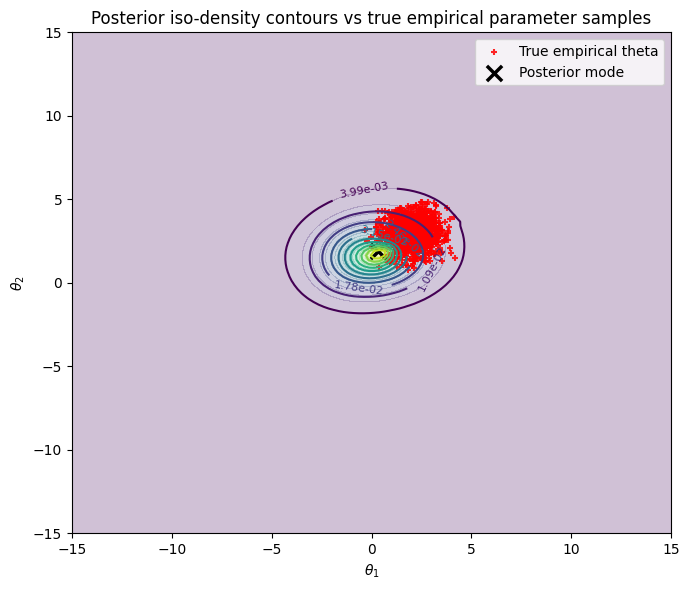

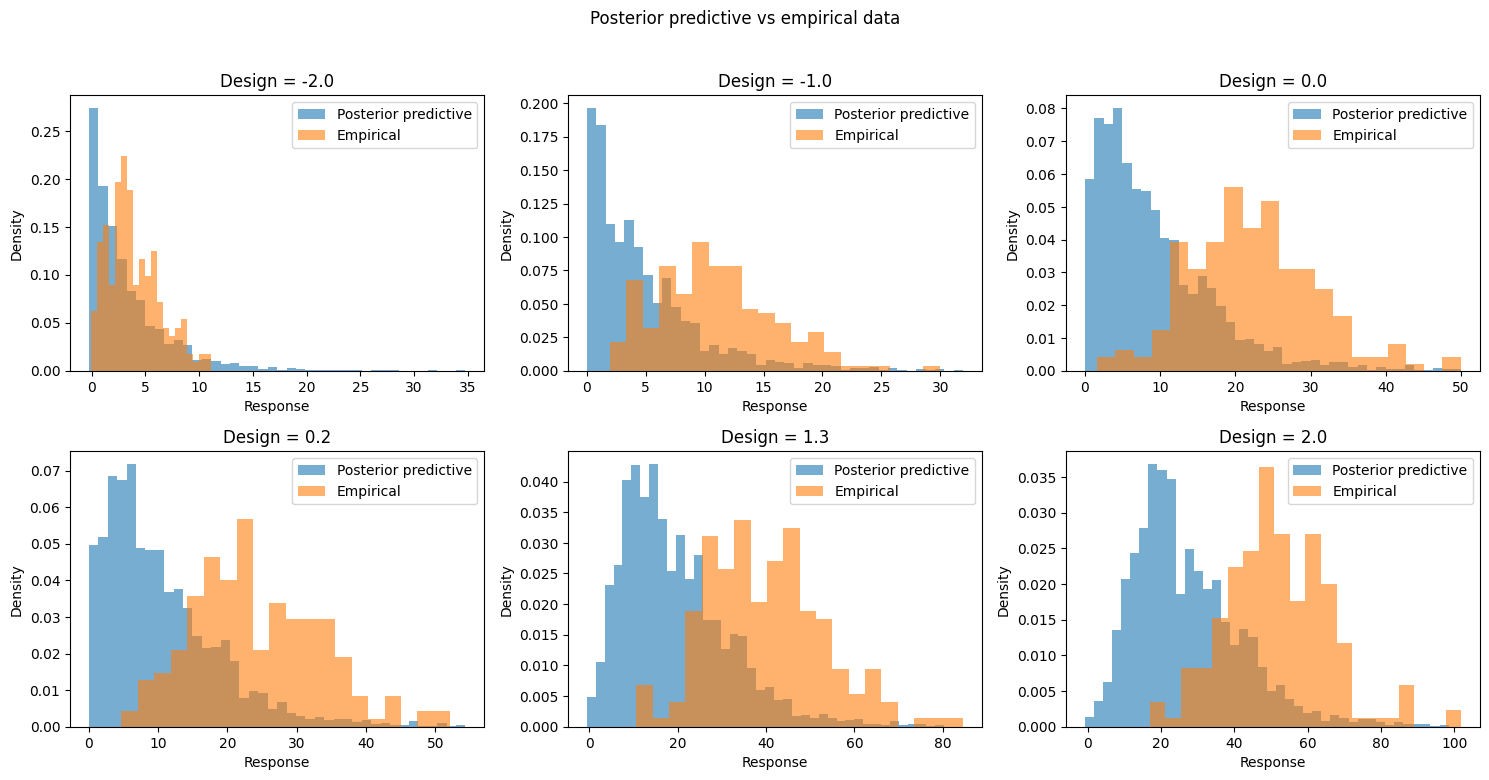

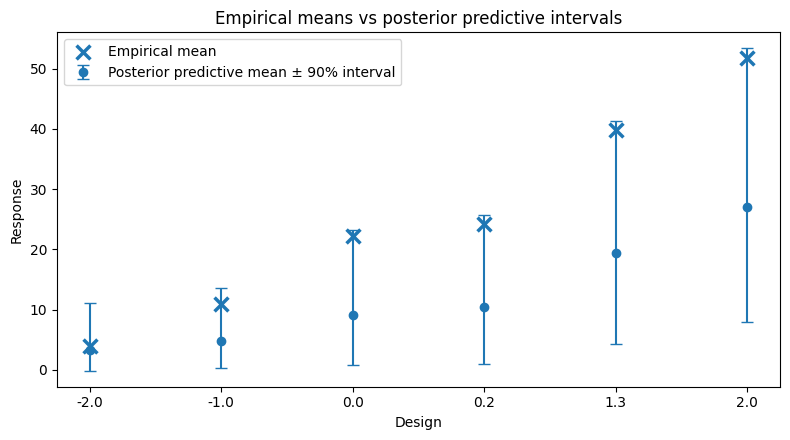

In [13]:
plot_posterior_vs_true_theta_case1(solver, Demp)
plot_posterior_predictive_vs_empirical(solver, n_post_samples=3000)
plot_empirical_vs_posterior_intervals(solver, n_post_samples=3000)

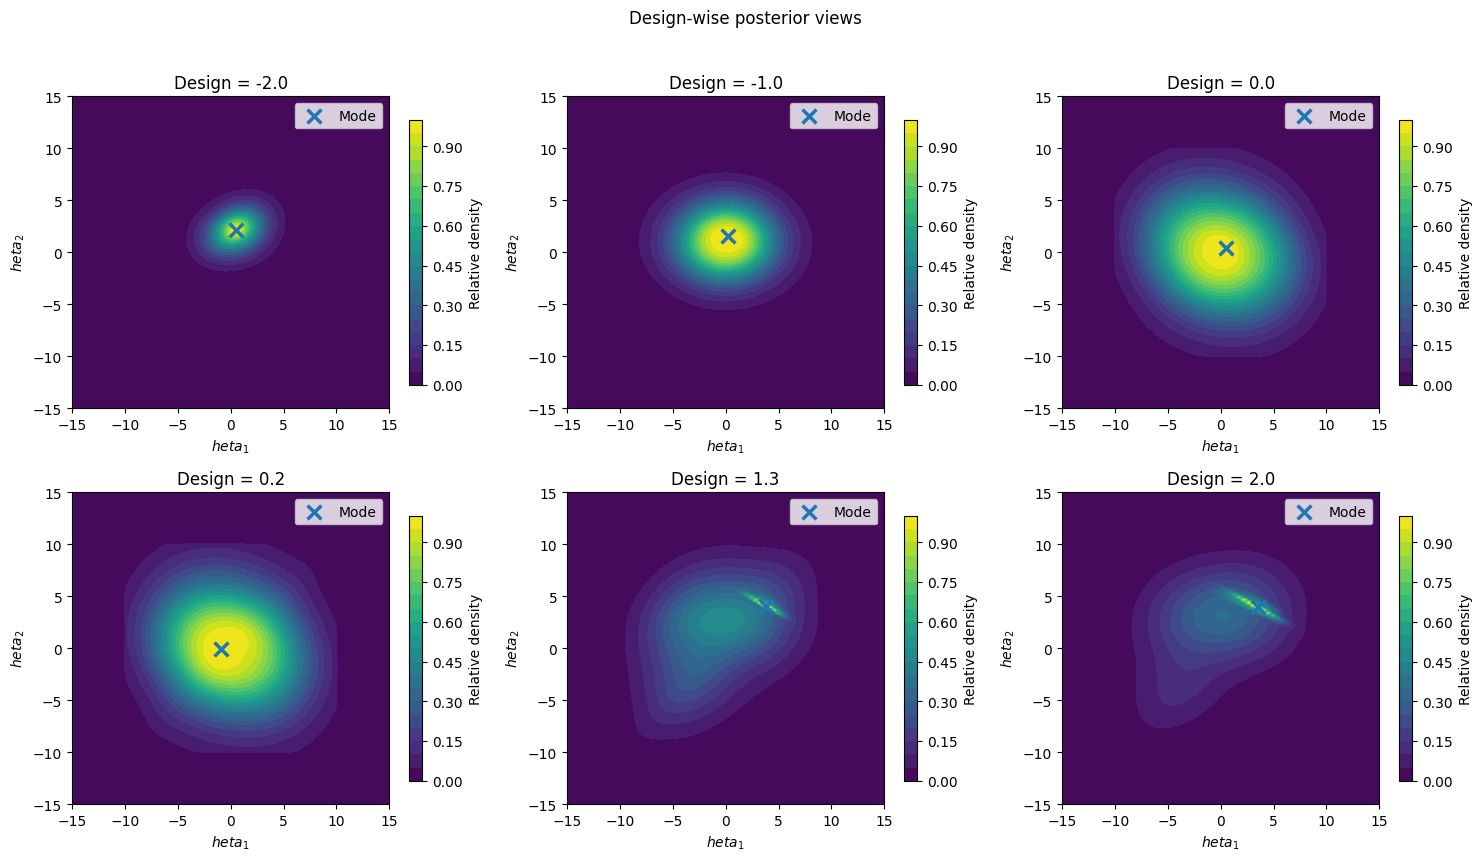

In [14]:
solver.fit_local_models()
plot_posterior_x_by_design_case1(solver)


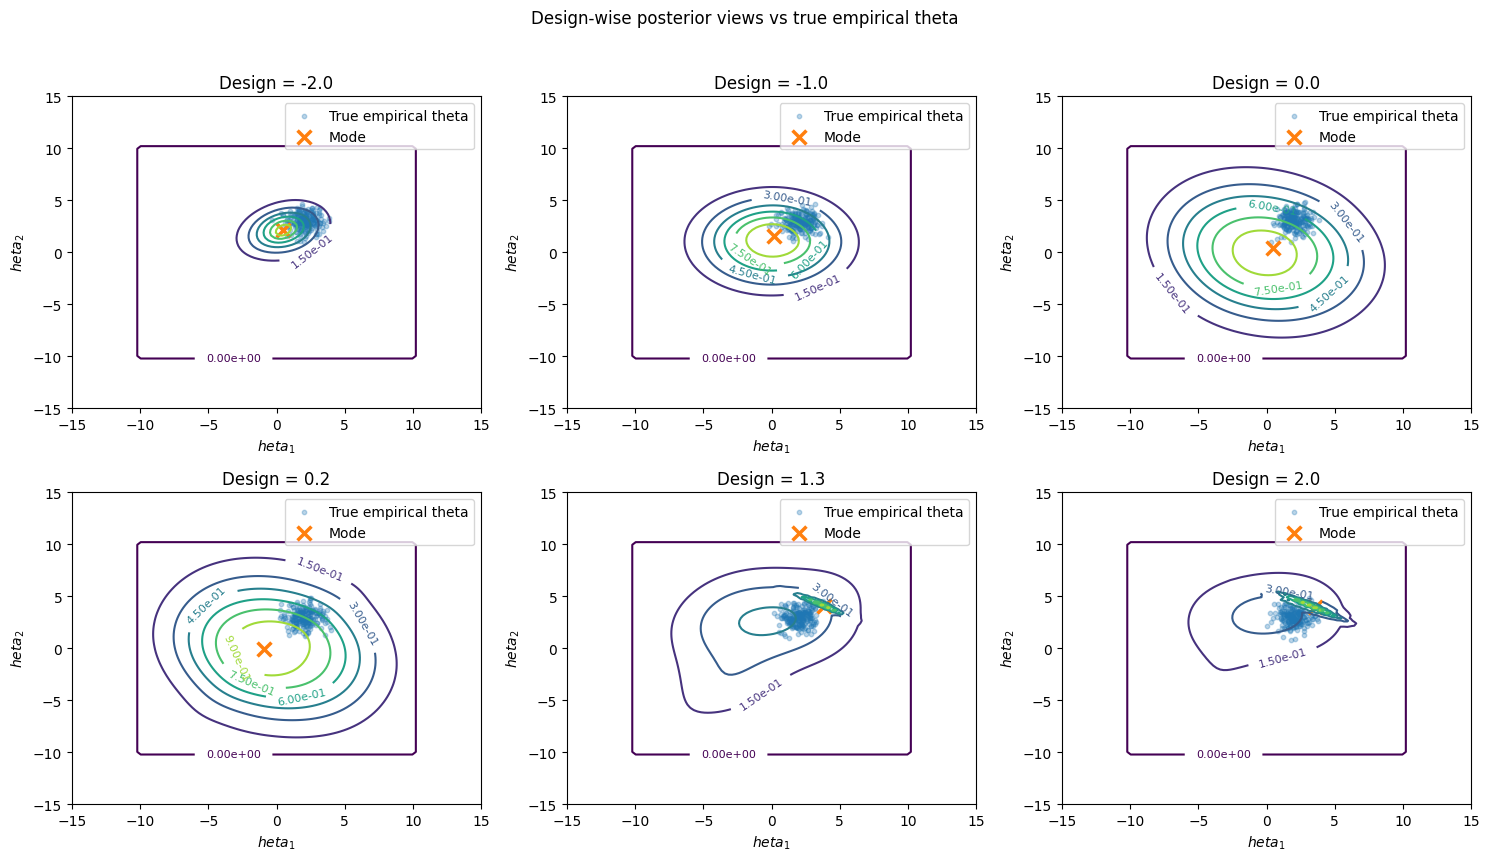

In [15]:
plot_posterior_vs_true_theta_by_design_case1(solver, Demp)

# USECASE 2 - AIRMODE

In [16]:

# ============================================================
# AIRMODE calibration workflow
# ============================================================
model_airmode, Y_emp_by_design, sim_db, prior = prepare_airmode_for_calibration(
    Nemp=30,
    Nsim=1000,
)

solver = SOLVER(
    model=model_airmode,
    Y_emp_by_design=Y_emp_by_design,
    prior=prior,
    sim_db=sim_db,
    K=20,
    ridge=1e-2,
    seed=123,
)

hist, diag = solver.adaptive_refine(
    max_iter=50,
    top_frac=0.1,
    n_new_per_iter=20,
    inflate=1.0,
    min_iter=20,
    improve_tol=0.001,
    patience=3,
)

print(hist)
print(diag.head())


Model loaded successfully
Expected input columns: ['theta1_front_bungee_k_znorm', 'theta2_rear_bungee_k_znorm', 'theta3_vtp_k_znorm', 'theta4_tail_joint_m_znorm', 'theta5_right_wingtip_m_znorm', 'theta6_left_wingtip_m_znorm', 'theta7_rl_wingtip_add_m_znorm', 'theta8_outer_wing_add_m_znorm', 'theta9_wf_joint_k_x_znorm', 'theta10_wf_joint_k_y_znorm', 'theta11_wf_joint_k_z_znorm', 'sigma_znorm']
Output columns: ['D1_roll', 'D2_pitch', 'D3_heave', 'D4_2ndEF_bend', 'D5_3rdEF_bend', 'D6_antisym_tors', 'D7_sym_tors', 'D8_vtp_bend', 'D9_4thEF_bend', 'D10_1stEF_foreaft']
[EMPIRICAL] Y_emp (from ../resources/AIRMODE/data/DLRAirmodData.mat) -> (30, 10)
[SIMULATED] X_sim -> (1000, 12)
[SIMULATED] Y_sim -> (1000, 10)
[iter 1/50] db=1000 pred=0.081 mean_radius=1.759 max_radius=1.804 flagged=3 truth_W=NA
[iter 2/50] db=1400 pred=0.05594 mean_radius=1.275 max_radius=1.306 flagged=3 truth_W=NA
[iter 3/50] db=1800 pred=0.04307 mean_radius=0.9213 max_radius=0.9522 flagged=3 truth_W=NA
[iter 4/50] db=2200

In [17]:
print("AIRMODE SUMMARY")
print(f"Initial mean radius: {hist['mean_radius'].iloc[0]:.4f}")
print(f"Final mean radius:   {hist['mean_radius'].iloc[-1]:.4f}")
print(f"Iterations:          {len(hist)}")
print(f"Stop reason:         {hist['stop_reason'].iloc[-1]}")

db_size_initial = sim_db["X"].shape[0]
db_size_final = solver.X_db.shape[0]
print(f"Database size:       {db_size_initial} -> {db_size_final}")


AIRMODE SUMMARY
Initial mean radius: 1.7587
Final mean radius:   0.4692
Iterations:          20
Stop reason:         predictive stagnation
Database size:       1000 -> 4600


[TMCMC] extracted from 'root.tmcmcSamples_reference' -> (100000, 11)


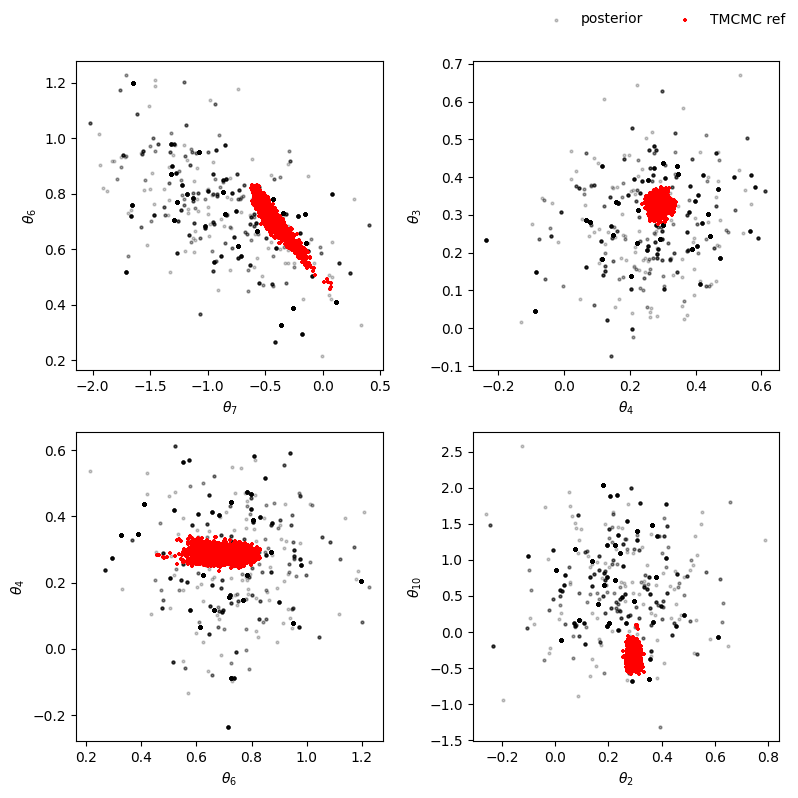

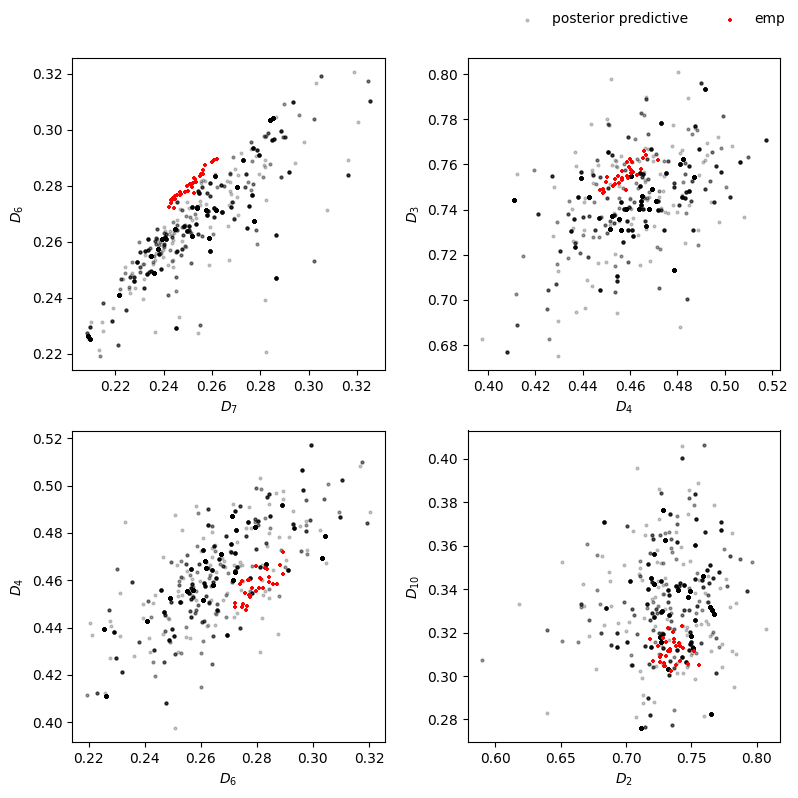

In [18]:
from resources.AIRMODE.load_helpers import *
# ---------- Paths ----------
ref_tmcmc_data_path = "../resources/AIRMODE/data/reference_TMCMC_DLRAirmod.mat"

# ---------- Load & extract TMCMC
tmobj = load_mat_any(str(ref_tmcmc_data_path))
theta_tmcmc, src_path = find_theta_matrix_from_mat(tmobj)
print(f"[TMCMC] extracted from '{src_path}' -> {theta_tmcmc.shape}")


X_post, Y_post = plot_airmode_posterior_style(
    solver=solver,
    theta_tmcmc=theta_tmcmc,
    theta_latex_names=[ r"$\theta_1$",  r"$\theta_2$", r"$\theta_3$",    r"$\theta_4$",  r"$\theta_5$", r"$\theta_6$",
                      r"$\theta_7$",  r"$\theta_8$", r"$\theta_9$",   r"$\theta_{10}$",  r"$\theta_{11}$"],
    Y_latex_names=[ r"$D_1$",  r"$D_2$", r"$D_3$",  r"$D_4$",  r"$D_5$", r"$D_6$",   r"$D_7$",  r"$D_8$", r"$D_9$",   r"$D_{10}$"],
    pairs_2_plt=[[6, 5], [3, 2], [5, 3], [1, 9]],
    plot_sim=False,
    n2plt=10_000,
    n_post=10_000,
    design="AIRMODE",
)